# Conditional VAE for Antimicrobial Peptide Generation

**Combines:**
- Baseline cVAE with APD6 data (5984 sequences, 7 binary conditions)
- Dean & Walper (ACS Omega 2020): LSTM architecture, character dropout, KL annealing
- Bowman et al. (2015): word dropout to prevent posterior collapse
- Latent interpolation & physicochemical property analysis

**Architecture:** LSTM encoder → 32D latent → LSTM decoder with condition injection

## 1. Data Loading

In [1]:
import numpy as np
import pandas as pd
import pickle
import math
import random
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from pathlib import Path
from tqdm.auto import tqdm, trange

# Project root (one level up from notebooks/)
ROOT = Path(__file__).resolve().parent.parent if '__file__' in dir() else Path(os.getcwd()).parent
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

print(f"Project root: {ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Models dir:   {MODELS_DIR}")

Project root: /Users/narly/Code/Study/S26/ExAI/explainable-VAE-for-AMP
Data dir:     /Users/narly/Code/Study/S26/ExAI/explainable-VAE-for-AMP/data
Models dir:   /Users/narly/Code/Study/S26/ExAI/explainable-VAE-for-AMP/models


/Users/narly/Code/Study/S26/ExAI/explainable-VAE-for-AMP/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load preprocessed APD6 data
DATA_PATH = DATA_DIR / "preprocessed" / "data.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"{DATA_PATH} not found — run data/notebooks/preprocessing.ipynb first")

df = pd.read_csv(DATA_PATH)

seq_col = 'Sequence'
len_col = 'Length'
condition_cols = [
    'is_antibacterial', 'is_anti_gram_positive', 'is_anti_gram_negative',
    'is_antifungal', 'is_antiviral', 'is_antiparasitic', 'is_anticancer'
]

existing_cols = [col for col in ['APD ID', seq_col, len_col] + condition_cols if col in df.columns]
df = df[existing_cols].dropna(subset=[seq_col])
for col in condition_cols:
    if col in df.columns:
        df[col] = df[col].astype(int)

print(f"Dataset size: {df.shape}")
print(f"\nCondition distribution:")
for col in condition_cols:
    print(f"  {col}: {df[col].sum()} positive ({df[col].mean()*100:.1f}%)")
df.head()

Dataset size: (5984, 10)

Condition distribution:
  is_antibacterial: 5136 positive (85.8%)
  is_anti_gram_positive: 4097 positive (68.5%)
  is_anti_gram_negative: 4393 positive (73.4%)
  is_antifungal: 1755 positive (29.3%)
  is_antiviral: 241 positive (4.0%)
  is_antiparasitic: 331 positive (5.5%)
  is_anticancer: 321 positive (5.4%)


,APD ID,Sequence,Length,is_antibacterial,is_anti_gram_positive,is_anti_gram_negative,is_antifungal,is_antiviral,is_antiparasitic,is_anticancer
0,AP00001,GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV,33,1,1,1,1,0,1,1
1,AP00002,YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY,34,1,1,1,0,0,0,0
2,AP00003,DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSV...,54,0,0,0,1,0,0,0
3,AP00004,NLCERASLTWTGNCGNTGHCDTQCRNWESAKHGACHKRGNWKCFCYFDC,49,1,1,0,1,0,0,0
4,AP00005,VFIDILDKVENAIHNAAQVGIGFAKPFEKLINPK,34,1,1,0,0,0,0,0


In [3]:
# Build vocabulary from sequences
all_chars = set()
for seq in df[seq_col]:
    all_chars.update(seq)

special_tokens = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']
vocab_list = special_tokens + sorted(all_chars)
char2idx = {ch: i for i, ch in enumerate(vocab_list)}
idx2char = {i: ch for ch, i in char2idx.items()}
vocab_size = len(vocab_list)

PAD_IDX = char2idx['<PAD>']
SOS_IDX = char2idx['<SOS>']
EOS_IDX = char2idx['<EOS>']
UNK_IDX = char2idx['<UNK>']

print(f"Vocabulary size: {vocab_size}")
print(f"Amino acids: {sorted(all_chars)}")

Vocabulary size: 24
Amino acids: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


In [4]:
def tokenize(seq, char2idx, max_len, add_sos_eos=True):
    """Convert sequence string to padded token indices."""
    tokens = [char2idx.get(ch, UNK_IDX) for ch in seq]
    if add_sos_eos:
        tokens = [SOS_IDX] + tokens + [EOS_IDX]
    if len(tokens) < max_len:
        tokens += [PAD_IDX] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]
    return tokens

# Max length with SOS/EOS
max_len = df[len_col].max() + 2
print(f"Max sequence length (with SOS/EOS): {max_len}")

# Tokenize all sequences
tokenized_seqs = [tokenize(seq, char2idx, max_len) for seq in df[seq_col]]
conditions = df[condition_cols].values.astype(np.float32)
real_lengths = np.array([min(len(seq) + 2, max_len) for seq in df[seq_col]])

Max sequence length (with SOS/EOS): 64


In [5]:
class AMPDataset(Dataset):
    """Dataset for antimicrobial peptide sequences with multi-hot conditions."""
    def __init__(self, sequences, lengths, conditions):
        self.sequences = torch.LongTensor(sequences)
        self.lengths = torch.LongTensor(lengths)
        self.conditions = torch.FloatTensor(conditions)  # multi-hot: peptide can have multiple activities

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.lengths[idx], self.conditions[idx]

dataset = AMPDataset(tokenized_seqs, real_lengths, conditions)

# Train/val/test split (80/10/10)
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 4787, Val: 598, Test: 599


## 2. Model Architecture

**Anti-collapse mitigations** (He et al. 2019; Lucas et al. 2019):
1. **Reduced decoder** (512 hidden) with stronger encoder (1024 hidden) — asymmetric power balance forces decoder to rely on z
2. **Free bits** (Kingma et al. 2016): per-dimension KL floor of 0.25 nats — mathematically prevents KL→0
3. **Cyclical KL annealing** (Fu et al. 2019): beta cycles 0→1 four times — periodically re-opens the information channel
4. **Lagging inference** (He et al. 2019): pre-train encoder for several steps before each decoder update in early epochs — gives encoder a head start
5. **z-injection at every timestep**: z+cond concatenated to decoder input at each step, not just init — decoder *must* attend to z throughout generation
6. **Character dropout** (Bowman et al. 2015): 30% rate (reduced from 50% to avoid routing-around)

In [6]:
# =====================================================================
# Hyperparameters (with anti-collapse mitigations)
# =====================================================================
embed_dim = 128             # Character embedding dimension
enc_hidden_dim = 1024       # Encoder LSTM hidden (strong encoder)
dec_hidden_dim = 512        # Decoder LSTM hidden (weaker decoder — forces z reliance)
latent_dim = 32             # Latent space dimension
cond_dim = len(condition_cols)  # 7 binary conditions
num_layers = 1              # Single LSTM layer
dropout = 0.2               # Embedding/output dropout
word_dropout_rate = 0.3     # Character dropout (reduced from 0.5 to prevent routing-around)
lr = 1e-3

# Anti-collapse settings
free_bits = 0.25            # Min KL per latent dim (nats) — prevents KL→0
cyclical_period = 10        # Epochs per beta cycle (0→1)
n_cycles = 4                # Number of full beta cycles
lagging_epochs = 10         # Epochs to use lagging inference
lagging_inner_steps = 5     # Encoder-only steps per decoder step during lagging

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Device: {device}")
print(f"\nHyperparameters:")
print(f"  enc_hidden={enc_hidden_dim}, dec_hidden={dec_hidden_dim}, latent={latent_dim}")
print(f"  word_dropout={word_dropout_rate}, free_bits={free_bits}")
print(f"  cyclical: {n_cycles} cycles x {cyclical_period} epochs")
print(f"  lagging inference: {lagging_epochs} epochs, {lagging_inner_steps} inner steps")

Device: mps

Hyperparameters:
  enc_hidden=1024, dec_hidden=512, latent=32
  word_dropout=0.3, free_bits=0.25
  cyclical: 4 cycles x 10 epochs
  lagging inference: 10 epochs, 5 inner steps


In [7]:
class Encoder(nn.Module):
    """
    Strong LSTM Encoder (1024 hidden).
    Asymmetric: encoder is more powerful than decoder to encourage
    putting information into z (He et al. 2019 / Lucas et al. 2019).
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, latent_dim, cond_dim, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.drop = nn.Dropout(dropout)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True)
        self.fc_mu = nn.Linear(hidden_dim + cond_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim + cond_dim, latent_dim)

    def forward(self, x, lengths, cond):
        embedded = self.drop(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu().clamp(min=1), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        hidden = h_n[-1]
        hidden_cond = torch.cat([hidden, cond], dim=1)
        return self.fc_mu(hidden_cond), self.fc_logvar(hidden_cond)


class Decoder(nn.Module):
    """
    Weaker LSTM Decoder (512 hidden) with z+cond injection at every timestep.

    Two anti-collapse mechanisms:
    1. Smaller hidden size than encoder — can't fully model sequences alone.
    2. z and cond are concatenated to the embedding at EVERY timestep
       (not just used for hidden-state init). The decoder sees z continuously,
       so it learns to depend on it rather than routing around via memory.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, latent_dim, cond_dim, dropout=0.2):
        super().__init__()
        self.latent_dim = latent_dim
        self.cond_dim = cond_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.drop = nn.Dropout(dropout)
        # LSTM input: embedding + z + cond at every step
        self.lstm = nn.LSTM(embed_dim + latent_dim + cond_dim, hidden_dim,
                            num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
        # Hidden/cell state init from z+cond (still useful for first step)
        self.init_h = nn.Linear(latent_dim + cond_dim, hidden_dim)
        self.init_c = nn.Linear(latent_dim + cond_dim, hidden_dim)

    def forward(self, x, z, cond, word_dropout_rate=0.0):
        batch_size, seq_len = x.shape
        z_cond = torch.cat([z, cond], dim=1)
        h0 = torch.tanh(self.init_h(z_cond)).unsqueeze(0)
        c0 = torch.tanh(self.init_c(z_cond)).unsqueeze(0)

        # Character dropout
        if self.training and word_dropout_rate > 0:
            mask = (torch.rand(batch_size, seq_len, device=x.device) < word_dropout_rate) & (x != PAD_IDX)
            x = x.clone()
            x[mask] = UNK_IDX

        embedded = self.drop(self.embedding(x))  # (batch, seq_len, embed_dim)

        # Concatenate z and cond to every timestep
        z_expand = z.unsqueeze(1).expand(-1, seq_len, -1)      # (batch, seq_len, latent_dim)
        cond_expand = cond.unsqueeze(1).expand(-1, seq_len, -1) # (batch, seq_len, cond_dim)
        lstm_input = torch.cat([embedded, z_expand, cond_expand], dim=2)

        outputs, _ = self.lstm(lstm_input, (h0, c0))
        return self.fc_out(outputs)


class CVAE(nn.Module):
    """
    Conditional VAE with anti-collapse architecture.
    - Asymmetric encoder (1024) > decoder (512)
    - z injected at every decoder timestep
    """
    def __init__(self, vocab_size, embed_dim, enc_hidden, dec_hidden,
                 latent_dim, cond_dim, dropout=0.2):
        super().__init__()
        self.encoder = Encoder(vocab_size, embed_dim, enc_hidden, latent_dim, cond_dim, dropout)
        self.decoder = Decoder(vocab_size, embed_dim, dec_hidden, latent_dim, cond_dim, dropout)
        self.latent_dim = latent_dim
        self.cond_dim = cond_dim

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            return mu + torch.randn_like(std) * std
        return mu

    def forward(self, src, lengths, cond, word_dropout_rate=0.0):
        mu, logvar = self.encoder(src, lengths, cond)
        z = self.reparameterize(mu, logvar)
        logits = self.decoder(src[:, :-1], z, cond, word_dropout_rate)
        return logits, src[:, 1:], mu, logvar


model = CVAE(vocab_size, embed_dim, enc_hidden_dim, dec_hidden_dim,
             latent_dim, cond_dim, dropout).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")
print(f"\nArchitecture:")
print(model)

Model parameters: 6,246,936

Architecture:
CVAE(
  (encoder): Encoder(
    (embedding): Embedding(24, 128, padding_idx=0)
    (drop): Dropout(p=0.2, inplace=False)
    (lstm): LSTM(128, 1024, batch_first=True)
    (fc_mu): Linear(in_features=1031, out_features=32, bias=True)
    (fc_logvar): Linear(in_features=1031, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(24, 128, padding_idx=0)
    (drop): Dropout(p=0.2, inplace=False)
    (lstm): LSTM(167, 512, batch_first=True)
    (fc_out): Linear(in_features=512, out_features=24, bias=True)
    (init_h): Linear(in_features=39, out_features=512, bias=True)
    (init_c): Linear(in_features=39, out_features=512, bias=True)
  )
)


## 3. Training

**Anti-collapse training strategy:**
- **Free bits** (Kingma et al. 2016): `KL_dim = max(KL_dim, 0.25)` — each latent dimension must carry at least 0.25 nats
- **Cyclical beta** (Fu et al. 2019): 4 cycles of linear 0→1, each over 10 epochs — re-opens the z channel periodically
- **Lagging inference** (He et al. 2019): during first 10 epochs, train encoder 5 extra steps per batch to give it a head start
- **Gradient clipping** (max norm 5.0) for stability
- **Early stopping** with patience=20

In [8]:
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)


def get_kl_weight(epoch):
    """
    Cyclical KL annealing (Fu et al. 2019).
    Beta linearly ramps 0→1 within each cycle, then resets.
    After all cycles complete, beta stays at 1.
    """
    total_anneal_epochs = n_cycles * cyclical_period
    if epoch >= total_anneal_epochs:
        return 1.0
    position_in_cycle = epoch % cyclical_period
    return position_in_cycle / max(1, cyclical_period - 1)


def loss_function(logits, target, mu, logvar, beta=1.0):
    """
    VAE loss with free bits (Kingma et al. 2016).
    
    Free bits: compute KL per latent dimension, clamp each to a minimum
    of `free_bits` nats. This prevents the encoder from zeroing out any
    dimension — each must carry at least `free_bits` of information.
    """
    recon_loss = criterion(logits.reshape(-1, vocab_size), target.reshape(-1))

    # Per-dimension KL: -0.5 * (1 + logvar - mu^2 - exp(logvar))
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())  # (batch, latent_dim)
    kl_per_dim = kl_per_dim.mean(dim=0)  # Average over batch → (latent_dim,)

    # Free bits: clamp each dimension to minimum
    kl_per_dim = torch.clamp(kl_per_dim, min=free_bits)
    kl_loss = kl_per_dim.sum()  # Sum over latent dims

    return recon_loss + beta * kl_loss, recon_loss, kl_loss


def train_epoch(model, loader, optimizer, epoch, use_lagging=False):
    """
    Train one epoch. If use_lagging=True, applies lagging inference
    (He et al. 2019): train encoder for extra steps before updating decoder.
    """
    model.train()
    total_loss, total_recon, total_kl = 0, 0, 0
    beta = get_kl_weight(epoch)
    pbar = tqdm(loader, desc=f"Train ep{epoch+1}", leave=False)

    for src, lengths, cond in pbar:
        src, lengths, cond = src.to(device), lengths.to(device), cond.to(device)

        # --- Lagging inference: extra encoder-only updates ---
        if use_lagging:
            for _ in range(lagging_inner_steps):
                optimizer.zero_grad()
                mu, logvar = model.encoder(src, lengths, cond)
                z = model.reparameterize(mu, logvar)
                # Decoder is used but its gradients are detached
                with torch.no_grad():
                    logits = model.decoder(src[:, :-1], z, cond, word_dropout_rate)
                target = src[:, 1:]
                # Recompute loss with encoder grads only
                logits_for_enc = model.decoder(src[:, :-1], z, cond, word_dropout_rate)
                loss_enc, _, _ = loss_function(logits_for_enc, target, mu, logvar, beta)
                # Zero decoder grads, keep encoder grads
                loss_enc.backward()
                for p in model.decoder.parameters():
                    if p.grad is not None:
                        p.grad.zero_()
                torch.nn.utils.clip_grad_norm_(model.encoder.parameters(), max_norm=5.0)
                optimizer.step()

        # --- Standard joint update ---
        optimizer.zero_grad()
        logits, target, mu, logvar = model(src, lengths, cond,
                                           word_dropout_rate=word_dropout_rate)
        loss, recon, kl = loss_function(logits, target, mu, logvar, beta)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", kl=f"{kl.item():.2f}", beta=f"{beta:.2f}")

    n = len(loader)
    return total_loss/n, total_recon/n, total_kl/n, beta


def eval_epoch(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, lengths, cond in tqdm(loader, desc="Val", leave=False):
            src, lengths, cond = src.to(device), lengths.to(device), cond.to(device)
            logits, target, mu, logvar = model(src, lengths, cond, word_dropout_rate=0.0)
            loss, _, _ = loss_function(logits, target, mu, logvar, beta=1.0)
            total_loss += loss.item()
    return total_loss / len(loader)

In [9]:
# Training loop with all anti-collapse mitigations
num_epochs = 150
best_val_loss = float('inf')
patience = 20  # Increased patience (cyclical annealing causes temporary val spikes)
counter = 0

history = {'train_loss': [], 'val_loss': [], 'recon': [], 'kl': [], 'beta': []}

BEST_MODEL_PATH = MODELS_DIR / "best_cvae.pt"

for epoch in trange(num_epochs, desc="Training"):
    # Lagging inference for first N epochs (He et al. 2019)
    use_lagging = epoch < lagging_epochs

    train_loss, recon, kl, beta = train_epoch(
        model, train_loader, optimizer, epoch, use_lagging=use_lagging
    )
    val_loss = eval_epoch(model, val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['recon'].append(recon)
    history['kl'].append(kl)
    history['beta'].append(beta)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        lag_str = " [lagging]" if use_lagging else ""
        tqdm.write(f"Epoch {epoch+1:3d}/{num_epochs} | "
                   f"Train: {train_loss:.4f} (R:{recon:.4f} KL:{kl:.4f}) | "
                   f"Val: {val_loss:.4f} | beta={beta:.2f}{lag_str}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        counter += 1
        if counter >= patience:
            tqdm.write(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(torch.load(BEST_MODEL_PATH, weights_only=True))
print(f"\nBest validation loss: {best_val_loss:.4f}")
print(f"Final KL: {history['kl'][-1]:.4f}")

Training:   1%|          | 1/150 [00:30<1:15:21, 30.35s/it]

Epoch   1/150 | Train: 2.8479 (R:2.8479 KL:939.2167) | Val: 586.7477 | beta=0.00 [lagging]


Training:   7%|▋         | 10/150 [03:57<56:40, 24.29s/it] 

Epoch  10/150 | Train: 10.3195 (R:2.2482 KL:8.0713) | Val: 10.1967 | beta=1.00 [lagging]


Training:  13%|█▎        | 20/150 [04:42<11:08,  5.14s/it]

...

Epoch 100/150 | Train: 9.5592 (R:1.3499 KL:8.2093) | Val: 9.6628 | beta=1.00


Training:  73%|███████▎  | 110/150 [10:56<02:36,  3.90s/it]

Epoch 110/150 | Train: 9.3926 (R:1.3223 KL:8.0703) | Val: 9.7989 | beta=1.00


Training:  79%|███████▉  | 119/150 [11:38<03:01,  5.87s/it]

Epoch 120/150 | Train: 9.3651 (R:1.2718 KL:8.0933) | Val: 9.7719 | beta=1.00
Early stopping at epoch 120

Best validation loss: 9.6628
Final KL: 8.0933


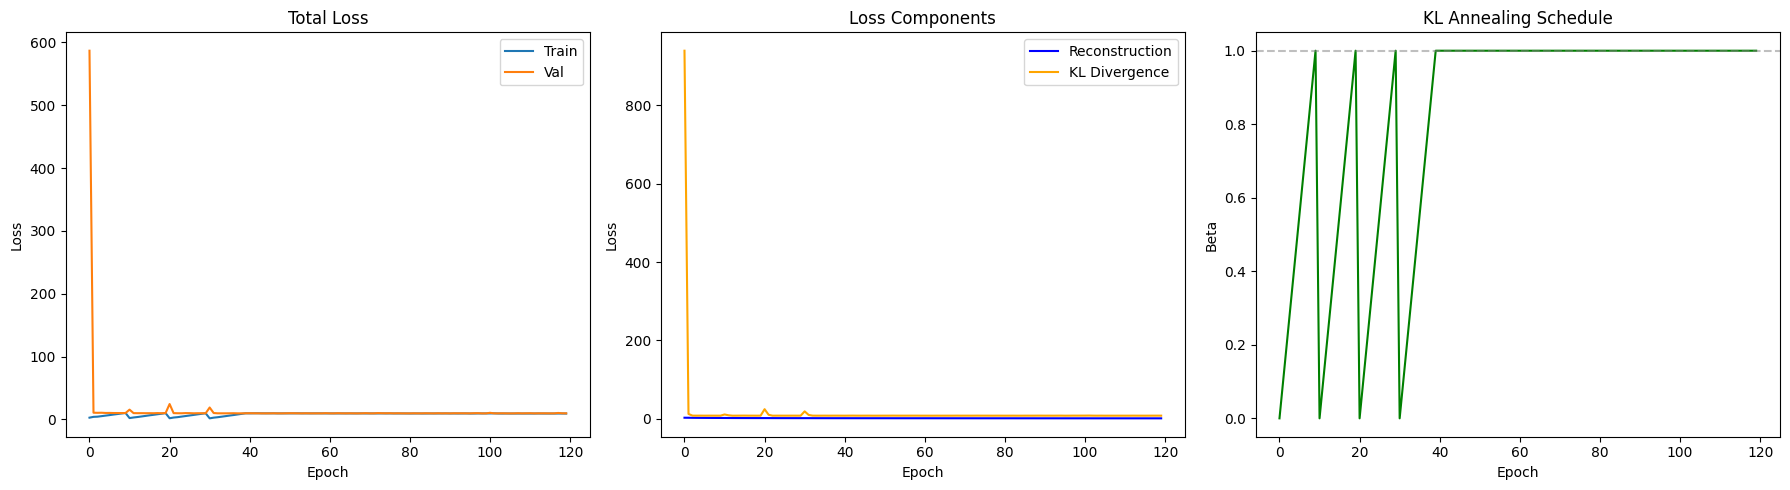

In [10]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Total Loss')
axes[0].legend()

axes[1].plot(history['recon'], label='Reconstruction', color='blue')
axes[1].plot(history['kl'], label='KL Divergence', color='orange')
axes[1].set(xlabel='Epoch', ylabel='Loss', title='Loss Components')
axes[1].legend()

axes[2].plot(history['beta'], color='green')
axes[2].set(xlabel='Epoch', ylabel='Beta', title='KL Annealing Schedule')
axes[2].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 4. Evaluation

Metrics:
- **Validity**: all characters are valid amino acids
- **Uniqueness**: fraction of non-duplicate generated sequences
- **Novelty**: fraction of generated sequences not in training set

In [11]:
def _decode_from_z_cond(model, z, cond_t, max_gen_len, temperature):
    """Shared autoregressive decoding logic for generation functions.

    Matches the new Decoder architecture: z+cond are concatenated to the
    embedding at every timestep (not just used for hidden-state init).
    """
    z_cond = torch.cat([z, cond_t], dim=1)
    h = torch.tanh(model.decoder.init_h(z_cond)).unsqueeze(0)
    c = torch.tanh(model.decoder.init_c(z_cond)).unsqueeze(0)

    input_token = torch.LongTensor([[SOS_IDX]]).to(device)
    generated = []
    for _ in range(max_gen_len):
        embedded = model.decoder.embedding(input_token)  # (1, 1, embed_dim)
        # Concatenate z and cond at this timestep (matches Decoder.forward)
        lstm_input = torch.cat([embedded, z.unsqueeze(1), cond_t.unsqueeze(1)], dim=2)
        output, (h, c) = model.decoder.lstm(lstm_input, (h, c))
        logits = model.decoder.fc_out(output.squeeze(1))
        probs = torch.softmax(logits / temperature, dim=-1)
        next_token = torch.multinomial(probs, 1).item()
        if next_token == EOS_IDX:
            break
        generated.append(next_token)
        input_token = torch.LongTensor([[next_token]]).to(device)

    return ''.join([idx2char[idx] for idx in generated
                    if idx not in [PAD_IDX, SOS_IDX, EOS_IDX]])


def generate(model, cond, max_gen_len=None, temperature=1.0, alpha=1.0):
    """
    Generate a peptide sequence from the cVAE.

    Args:
        model: trained CVAE model
        cond: condition vector (list of 7 binary values)
        max_gen_len: maximum generation length (default: max_len - 2)
        temperature: sampling temperature (higher = more diverse)
        alpha: condition strength in [0,1]. At alpha=0, condition is zeroed out
               (unconditional). At alpha=1, full condition.
    """
    if max_gen_len is None:
        max_gen_len = max_len - 2
    model.eval()
    with torch.no_grad():
        cond_t = torch.FloatTensor(cond).unsqueeze(0).to(device) * alpha
        z = torch.randn(1, latent_dim).to(device)
        return _decode_from_z_cond(model, z, cond_t, max_gen_len, temperature)


def generate_from_z(model, z, cond, max_gen_len=None, temperature=1.0, alpha=1.0):
    """Generate from a specific latent point z (for interpolation experiments)."""
    if max_gen_len is None:
        max_gen_len = max_len - 2
    model.eval()
    with torch.no_grad():
        if not isinstance(z, torch.Tensor):
            z = torch.FloatTensor(z).unsqueeze(0).to(device)
        cond_t = torch.FloatTensor(cond).unsqueeze(0).to(device) * alpha
        return _decode_from_z_cond(model, z, cond_t, max_gen_len, temperature)


# Quick test
cond_gram_pos = [0,1,0,0,0,0,0]
print("Sample generations for Gram+:")
for i in range(5):
    print(f"  {i+1}: {generate(model, cond_gram_pos)}")

Sample generations for Gram+:
  1: KWINVLACGKGSGVDFSCIALLNRTGGSASYLGDTVAVVLPAVAPKSPK
  2: ALLVTILGATKLVQPVPKRLQKNPKNFTKAFWKKRS
  3: GFGCNGPWSEDDLRCHRHCKSIKGYKGGYCAKGGFVCKCY
  4: GVLDILKQLGKAVLQGLLKTVADKLLCKITGC
  5: GLIKKFIKKLT


In [12]:
def evaluate_generation(model, cond, num_samples=200, train_seqs_set=None, alpha=1.0):
    """Compute Validity, Uniqueness, and Novelty metrics."""
    generated_seqs = [generate(model, cond, alpha=alpha)
                      for _ in trange(num_samples, desc="Generating", leave=False)]

    # Validity: all characters are standard amino acids
    valid_chars = set(all_chars)
    valid_seqs = [s for s in generated_seqs if len(s) > 0 and all(ch in valid_chars for ch in s)]
    validity = len(valid_seqs) / num_samples

    # Uniqueness
    unique_seqs = set(valid_seqs)
    uniqueness = len(unique_seqs) / len(valid_seqs) if valid_seqs else 0

    # Novelty
    if train_seqs_set is not None:
        novel_seqs = [s for s in unique_seqs if s not in train_seqs_set]
        novelty = len(novel_seqs) / len(unique_seqs) if unique_seqs else 0
    else:
        novelty = None

    return validity, uniqueness, novelty, valid_seqs


# Get training sequences for novelty check
train_seqs_raw = [df.iloc[i][seq_col] for i in train_dataset.indices]
train_seqs_set = set(train_seqs_raw)

# Evaluate for different conditions
conditions_to_test = {
    'Antibacterial':    [1,0,0,0,0,0,0],
    'Gram+':            [0,1,0,0,0,0,0],
    'Gram-':            [0,0,1,0,0,0,0],
    'Antifungal':       [0,0,0,1,0,0,0],
    'Antiviral':        [0,0,0,0,1,0,0],
    'Anticancer':       [0,0,0,0,0,0,1],
    'Multi (AB+G+)':    [1,1,0,0,0,0,0],
    'Unconditional':    [0,0,0,0,0,0,0],
}

print(f"{'Condition':<20} {'Validity':>10} {'Uniqueness':>10} {'Novelty':>10}")
print('-' * 55)
for name, cond in tqdm(conditions_to_test.items(), desc="Evaluating conditions"):
    v, u, n, _ = evaluate_generation(model, cond, num_samples=200, train_seqs_set=train_seqs_set)
    print(f"{name:<20} {v:>10.3f} {u:>10.3f} {n:>10.3f}")

Condition              Validity Uniqueness    Novelty
-------------------------------------------------------


Evaluating conditions:  12%|█▎        | 1/8 [00:07<00:55,  7.98s/it]

Antibacterial             1.000      1.000      0.975


Evaluating conditions:  25%|██▌       | 2/8 [00:15<00:44,  7.47s/it]

Gram+                     1.000      0.990      0.970


...

Anticancer                0.995      0.970      0.990


Evaluating conditions:  88%|████████▊ | 7/8 [00:53<00:07,  7.70s/it]

Multi (AB+G+)             1.000      0.995      0.955


Evaluating conditions: 100%|██████████| 8/8 [01:00<00:00,  7.60s/it]

Unconditional             1.000      0.995      0.995


In [29]:
# Save vocabulary
with open(MODELS_DIR / 'vocab.pkl', 'wb') as f:
    pickle.dump({
        'char2idx': char2idx, 'idx2char': idx2char,
        'max_len': max_len, 'vocab_list': vocab_list,
        'condition_cols': condition_cols
    }, f)

print(f"Saved to {MODELS_DIR}:")
print(f"  best_cvae.pt, parametric_tsne.pt, vocab.pkl")
print("Done!")

Saved to /Users/narly/Code/Study/S26/ExAI/explainable-VAE-for-AMP/models:
  best_cvae.pt, parametric_tsne.pt, vocab.pkl
Done!
